### Adaptive Corrective RAG

# Adaptive Corrective RAG using LangGraph

## Goal

This notebook implements an **Adaptive Corrective RAG** system.

The system can:

1. **Adaptively route** the user question to the right knowledge source.
2. **Retrieve documents** from a FAISS vectorstore.
3. **Grade retrieved documents** for relevance.
4. **Correct itself** if the retrieved documents are not useful.
5. **Rewrite the query** and retry retrieval.
6. **Fallback to Wikipedia** if vectorstore retrieval fails.
7. **Generate a final answer** using the best available context.

---

## What is Adaptive RAG?

Adaptive RAG means the system does not always use the same retrieval path.

Instead, it first understands the question and decides:

- Should I search my internal vector database?
- Should I use an external knowledge source like Wikipedia?

In this project:

- Questions about LangChain, LangGraph, RAG, agents, tools, embeddings, and model providers go to the **FAISS vectorstore**.
- General knowledge questions go to **Wikipedia**.

---

## What is Corrective RAG?

Corrective RAG means the system checks whether the retrieved documents are actually useful.

If the documents are relevant:

- The system generates the final answer.

If the documents are not relevant:

- The system rewrites the query.
- It retrieves again.
- If it still fails after retries, it falls back to Wikipedia.

This prevents the model from blindly answering using bad context.

---

## Graph Flow

```text
START
  |
  v
route_question
  |
  v
decide_retrieval_source
  |
  |------ vectorstore ------> retrieve
  |                              |
  |                              v
  |                         grade_documents
  |                              |
  |                              v
  |                         decide_to_generate
  |                              |
  |              good docs ------|------ bad docs
  |                 |                       |
  |                 v                       v
  |              generate          transform_query
  |                 |                       |
  |                 v                       v
  |                END                  retrieve
  |
  |------ wiki_search ------> generate ------> END

In [30]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

In [31]:
import os
from dotenv import load_dotenv
load_dotenv()




True

In [32]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [33]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrations

In [34]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

[Document(id='556460d6-e8fa-4527-8667-a68a1c4a3eca', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrate with providers using LangChain Python.', 'language': 'en'}, page_content='A provider is a company or platform that hosts AI models and exposes them through an API (e.g., OpenAI, Anthropic, Google). Many providers have a dedicated langchain-<provider> package that implements one or more of LangChain’s standard interfaces—chat models, embedding models, vector stores, and more—giving you a consistent API regardless of the underlying provider. Install the package, pick a model name, and swap providers without changing your code.'),
 Document(id='d89cb06a-e87a-437e-82be-4e76b6f6b7b9', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrat

In [35]:
from langchain_community.utilities import WikipediaAPIWrapper
# External Tool: Wikipedia

wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1500)

In [36]:
from typing import Dict, List
from pydantic import BaseModel, Field

class AdaptiveCorrectiveRAGState(TypedDict):
    question: str
    retrieval_mode: str
    query: str
    documents: List[Document]
    doc_score: str
    answer: str
    retry_count: int

In [37]:
# Add Structured output

class RouteQuery(BaseModel):
    datasource: Literal["vectorstore", "wiki_search"] = Field(
        description="Route to vectorstore if question is about LangChain docs, otherwise wiki_search"
    )


class GradeDocuments(BaseModel):
    binary_score: Literal["yes", "no"] = Field(
        description="yes if document is relevant to the question, otherwise no"
    )

In [38]:
# Create Question Router

structured_llm_router = llm.with_structured_output(RouteQuery)

route_prompt = PromptTemplate(
    template="""
You are an expert at routing a user question.

Use vectorstore for questions about:
- LangChain
- LangGraph
- agents
- RAG
- retrievers
- tools
- embeddings
- model providers

Use wiki_search for general world knowledge.

Question: {question}
""",
    input_variables=["question"],
)

question_router = route_prompt | structured_llm_router


In [39]:
structured_llm_grader = llm.with_structured_output(GradeDocuments)

grade_prompt = PromptTemplate(
    template="""
You are grading whether a retrieved document is relevant to a user question.

Retrieved document:
{document}

User question:
{question}

Return yes if relevant. Return no if not relevant.
""",
    input_variables=["document", "question"],
)

retrieval_grader = grade_prompt | structured_llm_grader

In [40]:
# Create Query writer
rewrite_prompt = PromptTemplate(
    template="""
You are rewriting a question to improve retrieval.

Original question:
{question}

Rewrite the question so it is more specific and retrieval-friendly.
Only return the rewritten question.
""",
    input_variables=["question"],
)

question_rewriter = rewrite_prompt | llm | StrOutputParser()

In [41]:
# create answer generator

generate_prompt = PromptTemplate(
    template="""
You are an AI assistant. Answer the question using only the provided context.

Question:
{question}

Context:
{context}

Answer:
""",
    input_variables=["question", "context"],
)

rag_chain = generate_prompt | llm | StrOutputParser()

In [42]:
# create graph nodes

def route_question_node(state: AdaptiveCorrectiveRAGState):
    print("---ROUTE QUESTION---")

    question = state["question"]
    route = question_router.invoke({"question": question})

    return {
        "retrieval_mode": route.datasource,
        "query": question,
        "retry_count": 0
    }

In [43]:
def retrieve_node(state: AdaptiveCorrectiveRAGState):
    print("---RETRIEVE FROM VECTORSTORE---")

    query = state["query"]
    documents = retriever.invoke(query)

    return {
        "documents": documents
    }

In [44]:
def wiki_search_node(state: AdaptiveCorrectiveRAGState):
    print("---WIKI SEARCH---")

    question = state["question"]
    wiki_result = wiki.run(question)

    doc = Document(page_content=wiki_result)

    return {
        "documents": [doc],
        "doc_score": "yes"
    }

In [45]:
def grade_documents_node(state: AdaptiveCorrectiveRAGState):
    print("---GRADE DOCUMENTS---")

    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for doc in documents:
        score = retrieval_grader.invoke({
            "question": question,
            "document": doc.page_content
        })

        if score.binary_score == "yes":
            filtered_docs.append(doc)

    if filtered_docs:
        return {
            "documents": filtered_docs,
            "doc_score": "yes"
        }

    return {
        "documents": [],
        "doc_score": "no"
    }

In [46]:
def transform_query_node(state: AdaptiveCorrectiveRAGState):
    print("---TRANSFORM QUERY---")

    question = state["question"]
    retry_count = state["retry_count"] + 1

    better_query = question_rewriter.invoke({
        "question": question
    })

    return {
        "query": better_query,
        "retry_count": retry_count
    }

In [47]:
def generate_node(state: AdaptiveCorrectiveRAGState):
    print("---GENERATE ANSWER---")

    question = state["question"]
    documents = state["documents"]

    context = "\n\n".join([doc.page_content for doc in documents])

    answer = rag_chain.invoke({
        "question": question,
        "context": context
    })

    return {
        "answer": answer
    }

In [48]:
# Add routing functions
def decide_retrieval_source(state: AdaptiveCorrectiveRAGState):
    if state["retrieval_mode"] == "wiki_search":
        return "wiki_search"

    return "retrieve"

In [49]:
def decide_to_generate(state: AdaptiveCorrectiveRAGState):
    print("---DECIDE TO GENERATE---")

    if state["doc_score"] == "yes":
        return "generate"

    if state["retry_count"] < 2:
        return "transform_query"

    return "wiki_search"

In [50]:
# Gra[h Construction

workflow = StateGraph(AdaptiveCorrectiveRAGState)

workflow.add_node("route_question", route_question_node)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("wiki_search", wiki_search_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("transform_query", transform_query_node)
workflow.add_node("generate", generate_node)

workflow.add_edge(START, "route_question")

workflow.add_conditional_edges(
    "route_question",
    decide_retrieval_source,
    {
        "retrieve": "retrieve",
        "wiki_search": "wiki_search"
    }
)

workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "generate": "generate",
        "transform_query": "transform_query",
        "wiki_search": "wiki_search"
    }
)

workflow.add_edge("transform_query", "retrieve")
workflow.add_edge("wiki_search", "generate")
workflow.add_edge("generate", END)

graph = workflow.compile()

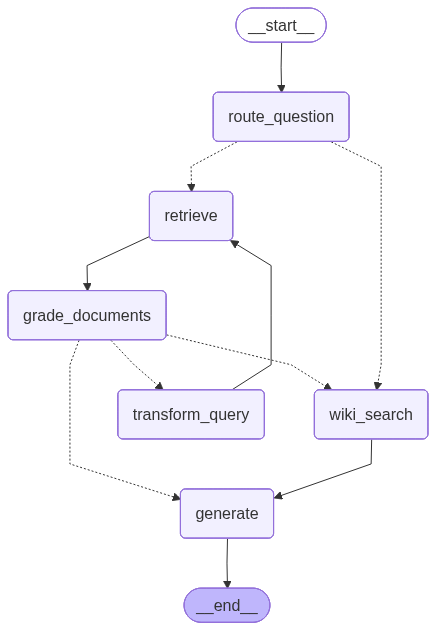

In [51]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
inputs = {
    "question": "What is LangGraph and how does it help build agents?",
    "retrieval_mode": "",
    "query": "",
    "documents": [],
    "doc_score": "",
    "answer": "",
    "retry_count": 0
}

result = graph.invoke(inputs)

print(result["answer"])

---ROUTE QUESTION---
---RETRIEVE FROM VECTORSTORE---
---GRADE DOCUMENTS---
---DECIDE TO GENERATE---
---GENERATE ANSWER---
<think>
Okay, let me try to figure this out. The user is asking what LangGraph is and how it helps in building agents. I need to use the provided context to answer this.

Looking at the context, it mentions that LangChain's agents are built on top of LangGraph. So, LangGraph seems to be the underlying framework. The first paragraph says that LangGraph provides durable execution, human-in-the-loop support, persistence, and more. That's a good start. The user probably wants to know what LangGraph does and its role in building agents.

The second part of the context compares LangChain, LangGraph, and Deep Agents. It says that LangGraph is the low-level orchestration framework used for advanced needs combining deterministic and agentic workflows. So, LangGraph is a lower-level tool compared to LangChain agents. It allows for more complex workflows that mix both determin

In [53]:
inputs = {
    "question": "Who is Albert Einstein?",
    "retrieval_mode": "",
    "query": "",
    "documents": [],
    "doc_score": "",
    "answer": "",
    "retry_count": 0
}

result = graph.invoke(inputs)

print(result["answer"])

---ROUTE QUESTION---
---WIKI SEARCH---
---GENERATE ANSWER---
<think>
Okay, let's see. The user is asking who Albert Einstein is. I need to answer based on the provided context. Let me check the context pages given.

First, there's the page about Hans Albert Einstein. It mentions that Hans Albert was the son of Albert Einstein and Mileva Marić. So, Albert Einstein is Hans's father. But the summary about Hans doesn't give much about Albert himself. 

Then there's the Einstein family page. It says Albert Einstein was born in 1879 and died in 1955. His family is discussed, including his fourth-great-grandfather and second-great-grandfather. His children with Mileva Marić include Lieserl and Hans Albert. Also, his second wife was Elsa Einstein, who was his first cousin through their mothers. 

The question is asking about Albert Einstein, so I need to piece together the information. The context doesn't mention his profession or his work, like the theory of relativity or the famous E=mc² equ